# PedSilicoICH: Part 3. Running Studies

This notebook combines the pieces from [01_phantoms.ipynb](01_phantoms.ipynb) and [02_scanners.ipynb]() into the full pipeline, checkout those notebooks for more in depth coverage of each

## Introduction

The purpose of this notebook is to demonstrate how to run CT simulations using open-source head phantoms as a part of **Aim 1.3** with the [XCIST](https://github.com/xcist/main) CT simulation framework.

![](../project_aims.png)
*This notebook focuses on Aim 1.3, CT Dataset Generation Pipeline*

###  Why Virtual Imaging Trials?

Data driven methods like AI have enabled innovation in medical devices and clinical practice by leveraging large data sources to solve previously intractable problems in medical imaging including image reconstruction, segmentation and classification. However, any data driven method is at risk of bias and over fitting on sparse and noisey training sets and are liable to drift to changing data sources in production. Developing large, diverse high quality test sets is an important mitigation to model bias and drift but becomes challenging when considering including rare diseases and underrepresented groups such as pediatrics into device development and evaluation. In addition, pediatrics have special protections on data access further challenging their inclusing in training and testing datasets. Thus in silico modeling of patients, diseases, and imaging systems will be another essential mitigation factor enabling high quality labeled data where ground truth is known exactly and can be produced sustainably compared to traditional clinical trials and retrospective collection. 

This work aims to devloped in silico disease models of large vessel occlusions that can be modeled for pediatric evaluation of LVO cadt devices.


In [1]:
from insilicoICH.recruit_study import generate_input_df
generate_input_df?

Signature:
generate_input_df(
    output_directory='results',
    views=[1000],
    desired_cases=1,
    zspan='dynamic',
    age=[0, 100],
    subtypes=[None, 'IPH', 'EDH', 'SDH'],
    mass_effect=True,
    edema=[0, 15],
    volume={'IPH': [0.1, 60], 'EDH': [0.1, 60], 'SDH': [0.1, 60]},
    attenuation={'IPH': [0, 90], 'EDH': [0, 90], 'SDH': [0, 90]},
    scanner=['Scanner_Default'],
    kVp=[120],
    mA=[300],
    pitch=[0],
    save_name=None,
    kernel=['soft'],
    slice_thickness=[1],
    slice_increment=[1],
    keep_raw=False,
    seed=None,
)
Docstring: <no docstring>
File:      ~/Dev/PedSilicoICH/src/insilicoICH/recruit_study.py
Type:      function

In [4]:
input_df = generate_input_df(desired_cases=2)
input_df

,CaseID,Age,Scanner,kVp,mA,Pitch,Views,ScanCoverage,ReconKernel,SliceThickness(mm),SliceIncrement(mm),LesionAttenuation(HU),Subtype,LesionVolume(mL),Edema,MassEffect,GlobalSeed,CaseSeed,OutputDirectory
0,case_000,15.75,Scanner_Default,120.0,300.0,0.0,1000.0,dynamic,soft,1,1,0.000000,None,0.000000,0,True,825028,319030,results
1,case_001,0.00,Scanner_Default,120.0,300.0,0.0,1000.0,dynamic,soft,1,1,84.489796,IPH,19.659184,12,True,825028,305653,results


In [ ]:
from pathlib import Path

def get_scans_completed(input_csv):
    scans_completed = 0
    for idx in range(len(input_csv)):
        output_dir = Path(input_csv.iloc[idx]['OutputDirectory'])
        try:
            metadata_files = list(output_dir.rglob('metadata_*.csv'))
        except FileNotFoundError:
            continue
        if len(metadata_files) > 0:
            scans_completed += 1
    return scans_completed

In [ ]:
from subprocess import run

parallel = True
output = Path(input_df.iloc[0]['OutputDirectory'])

if parallel:
    out = run(["bash", str(block_dir / "run_batchmode.sh"),
                str(block_dir / 'batchmode_CT_dataset_pipeline.sge'),
                csv_fname])
    returncode = out.returncode
if returncode:
    print('Running batch mode in serial.')
    insilicoich(input_csv=csv_fname)

scans_queued = len(input_df)
scans_completed = get_scans_completed(input_df)
with tqdm(total=scans_queued, desc='Scans completed in parallel') as pbar:
    while scans_completed < scans_queued:
        sleep(1)
        if get_scans_completed(input_df) > scans_completed:
            pbar.update(get_scans_completed(input_df) - scans_completed)
            scans_completed = get_scans_completed(input_df)

In [33]:
import numpy as np
from VITools import Scanner

from insilicoICH import load_phantom

age = 6.5
phantom = load_phantom(age)

volumes = np.linspace(0.05, 0.5, 3)
intensities = np.linspace(80, 50, 3)
lesion_type = 'IPH'

lesions = []
for intensity, volume in zip(intensities, volumes):
    lesion_definition = dict(
        volume=volume,
        intensity=intensity,
        lesion_type=lesion_type,
        seed=336  # optional for reproducibility
    )
    lesions.append(lesion_definition)

for idx, lesion in enumerate(lesions):
    print(f'inserting lesion {idx}/{len(lesions)}:\n{lesion}\n')
    phantom.insert_lesion(**lesion)

scanner = Scanner(phantom)
scanner

inserting lesion 0/3:
{'volume': np.float64(0.05), 'intensity': np.float64(80.0), 'lesion_type': 'IPH', 'seed': 336}

inserting lesion 1/3:
{'volume': np.float64(0.275), 'intensity': np.float64(65.0), 'lesion_type': 'IPH', 'seed': 336}

inserting lesion 2/3:
{'volume': np.float64(0.5), 'intensity': np.float64(50.0), 'lesion_type': 'IPH', 'seed': 336}

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 0.800000011920929-mm pixels (XY), 0.800000011920929-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ncat_adipose', 'ncat_water', 'ncat_brain', 'ncat_skull']
* mu values (/cm): [


        <class 'VITools.image_acquisition.Scanner'> default
        Scanner: Scanner_Default
        Simulation Platform: CATSIM
        

7


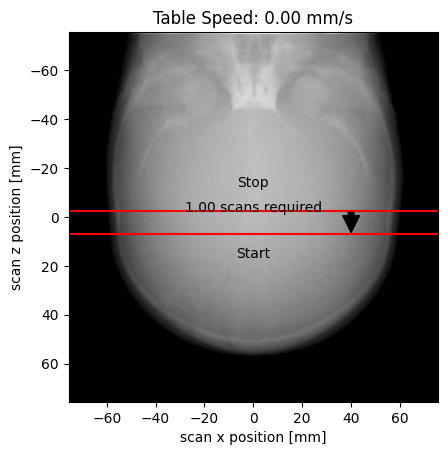

In [34]:
lesion_level_mm = (phantom.get_CT_number_phantom().shape[0]/2 -
                   phantom._lesion_coords[0][0])*phantom.dz

scans = 1  # edit me

center = lesion_level_mm
scan_width = 7

width = scan_width*scans
print(width)
startZ = center - width / 2
endZ = center + width / 2

scanner.scout_view(startZ, endZ)

In [35]:
acquisition_technique = dict(
    mA=200,
    kVp=120,
    views=1000,
    startZ=startZ,
    endZ=endZ
)

recon_technique = dict(
    kernel='soft',
    fov=250,
    sliceThickness=1
)

The `Study` object holds both the patient `Phantom` instance and the scanner `Scanner` instance (`Phantom` is a scanner attribute) and stores the relevant scan details

In [36]:
from insilicoICH.study import Study
study = Study(scanner)
study


        study name: default
        Phantom details:
        ----------------
        
        Phantom Class: NIHPD_Head
        Age (years): 6.5
        Shape (voxels): [189, 233, 197]
        Size (mm): [151.20000225 186.40000278 157.60000235]
        
        Number of lesions: 3
        Lesion locations [voxel index (z, x, y)]: [(np.int64(93), np.int64(175), np.int64(111)), (np.int64(93), np.int64(83), np.int64(131)), (np.int64(92), np.int64(149), np.int64(128))]
        Mass effect: False
        

        Scanner details:
        ----------------
        Scanner: 
        <class 'VITools.image_acquisition.Scanner'> default
        Scanner: Scanner_Default
        Simulation Platform: CATSIM
        

        Study details:
        --------------
        None
        

In [37]:
acquisition_technique['zspan'] = (startZ, endZ)
study.run_study(**acquisition_technique, **recon_technique)
study.metadata

scan: 1/1
Airscan
Offset scan
Phantom scan


  0%|          | 0/1000 [00:00<?, ?it/s]

in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    264 MB.


100%|██████████| 1000/1000 [04:13<00:00,  3.94it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 0.800000011920929-mm pixels (XY), 0.800000011920929-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified i

...

  1%|          | 1/100 [00:00<01:31,  1.08it/s]

in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated a total of     66 MB.


100%|██████████| 100/100 [00:08<00:00, 11.75it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...


,Name,Age,kVp,mA,Views,ReconKernel,SliceThickness(mm),LesionAttenuation(HU),LesionVolume(mL),Subtype,MassEffect,CenterX,CenterY,CenterZ,FOV(mm),ImageFilePath,MaskFilePath
0,6.5 yr NIHPD Head,6.5,120,200,1000,soft,1,None,[0.0],None,None,NaN,NaN,NaN,250,/tmp/tmpwh___1en/6.5 yr NIHPD Head/dicoms/6.5 ...,/tmp/tmpwh___1en/6.5 yr NIHPD Head/lesion_mask...
1,6.5 yr NIHPD Head,6.5,120,200,1000,soft,1,None,[0.0],None,None,NaN,NaN,NaN,250,/tmp/tmpwh___1en/6.5 yr NIHPD Head/dicoms/6.5 ...,/tmp/tmpwh___1en/6.5 yr NIHPD Head/lesion_mask...
2,6.5 yr NIHPD Head,6.5,120,200,1000,soft,1,None,[0.0],None,None,NaN,NaN,NaN,250,/tmp/tmpwh___1en/6.5 yr NIHPD Head/dicoms/6.5 ...,/tmp/tmpwh___1en/6.5 yr NIHPD Head/lesion_mask...
3,6.5 yr NIHPD Head,6.5,120,200,1000,soft,1,None,[0.0],None,None,NaN,NaN,NaN,250,/tmp/tmpwh___1en/6.5 yr NIHPD Head/dicoms/6.5 ...,/tmp/tmpwh___1en/6.5 yr NIHPD Head/lesion_mask...
4,6.5 yr NIHPD Head,6.5,120,200,1000,soft,1,None,[0.0],None,None,NaN,NaN,NaN,250,/tmp/tmpwh___1en/6.5 yr NIHPD Head/dicoms/6.5 ...,/tmp/tmpwh___1en/6.5 yr NIHPD Head/lesion_mask...
5,6.5 yr NIHPD Head,6.5,120,200,1000,soft,1,"[80.0, 65.0, 50.0]",[0.05626678466796875],"[IPH, IPH, IPH]",False,352.0,277.0,5.0,250,/tmp/tmpwh___1en/6.5 yr NIHPD Head/dicoms/6.5 ...,/tmp/tmpwh___1en/6.5 yr NIHPD Head/lesion_mask...
6,6.5 yr NIHPD Head,6.5,120,200,1000,soft,1,"[80.0, 65.0, 50.0]",[0.06890296936035156],"[IPH, IPH, IPH]",False,352.0,277.0,5.0,250,/tmp/tmpwh___1en/6.5 yr NIHPD Head/dicoms/6.5 ...,/tmp/tmpwh___1en/6.5 yr NIHPD Head/lesion_mask...


In [38]:
%pip install -q matplotlib ipywidgets

Note: you may need to restart the kernel to use updated packages.


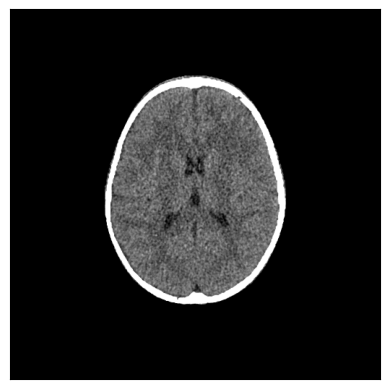

In [39]:
from utils import ctshow
ctshow(study.scanner.recon, 'brain')

In [40]:
from utils import scrollview
scrollview(study.scanner.recon, 'brain')

interactive(children=(IntSlider(value=3, description='idx', max=6), Output()), _dom_classes=('widget-interact'…

In [41]:
study.images.shape, study.lesion.shape

((7, 512, 512), (7, 512, 512))

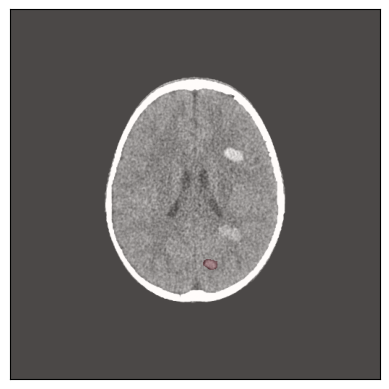

In [42]:
import matplotlib.pyplot as plt
z = int(study.lesion_coords[0])
ctshow(study.images[z], 'brain')
plt.imshow(study.lesion[z], cmap='Reds', alpha=0.3)

## Going in Deeper

Below are more details on other specific features

### Working with `Phantoms`

Define the base healthy phantom head to be imaged

This notebook introduces running simulations with [MIDA head phantom](https://www.fda.gov/medical-devices/science-and-research-medical-devices/mida-multimodal-imaging-based-model-human-head-and-neck), a segmented MRI head model consisting of over 100 + segmented regions. The dataset is assumed to be downloaded in repository's root directory but you can modifiy `phantom_dir` accordingly if you have it else where

#### MIDA Head

Thus to prepare the MIDA phantom for XCIST simulations we'll add a column called `xcist material` such that we can group several specific MIDA segmentation labels under a common, more broad label and assign it the same CT number. For example there are several anatomic regions in the MIDA phantom that are all primarily gray matter so we will assign them the xcist label of 'gray_matter' and given them a common CT number, see here for some reasonable CT numbers of materials: https://en.wikipedia.org/wiki/Hounsfield_scale#Values_for_different_body_tissues_and_material

*Note: these CT numbers are estimates and are just for making the volume fraction maps, they will differ in the final simulation depending on the chose kVp settings.*

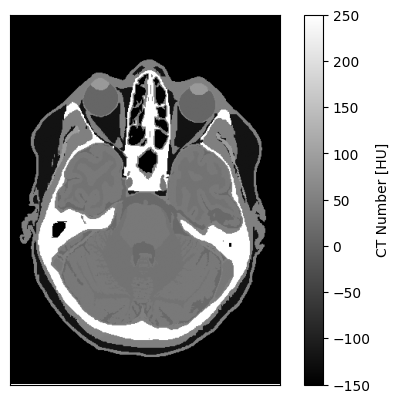

In [43]:
from pathlib import Path
from dotenv import load_dotenv
import os
import matplotlib.pyplot as plt

from insilicoICH.phantoms.head_phantoms import MIDA_Head

import sys
sys.path.append('..')
from utils import ctshow

load_dotenv()
if 'PHANTOM_DIRECTORY' not in os.environ:
    raise ValueError('''
Please `export PHANTOM_DIRECTORY=/path/to/phantoms` or add your `.env` file with PHANTOM_DIRECTORY=/path/to/phantoms
''')
phantom_dir = Path(os.environ['PHANTOM_DIRECTORY'])
mida_dir = phantom_dir / 'MIDA_Head_Phantom'
mida = MIDA_Head(mida_dir)

im = ctshow(mida.get_CT_number_phantom()[250])
plt.colorbar(im, label='CT Number [HU]')

In [44]:
MIDA_Head.ages

[38.0]

#### NIHPD Brain Atlas

In [45]:
from insilicoICH.phantoms.head_phantoms import possible_ages

In [46]:
possible_ages

[0.0, 1.0, 2.0, 6.5, 9.0, 10.5, 11.5, 12.0, 15.75, 38.0]

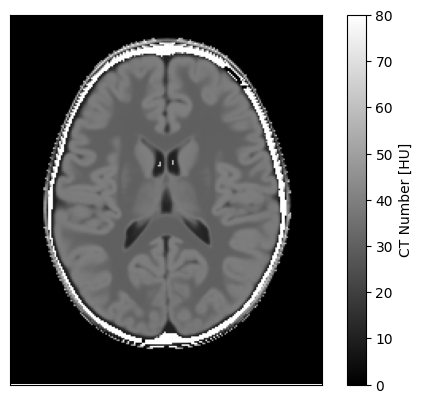

In [47]:
from insilicoICH.phantoms.head_phantoms import NIHPD_Head

age = 6.5

nihpd_dir = phantom_dir / 'NIHPD_Head_Phantom'
nihpd = NIHPD_Head(nihpd_dir, age=age)

im = ctshow(nihpd.get_CT_number_phantom()[100], 'brain')
plt.colorbar(im, label='CT Number [HU]')

In [48]:
NIHPD_Head.ages

[6.5, 9.0, 10.5, 11.5, 12.0, 15.75]

#### Select Phantom Based on Age

6.5


Text(0.5, 1.0, '6.5')

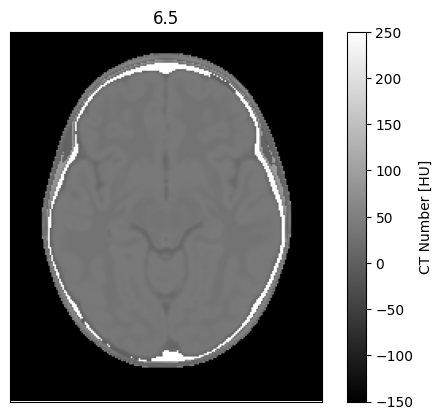

In [49]:
from random import choice

age = choice(possible_ages)
age = 6.5
print(age)

if age == MIDA_Head.ages[0]:
    phantom = MIDA_Head(mida_dir)
else:
    phantom = NIHPD_Head(nihpd_dir, age=age)

ground_truth = phantom.get_CT_number_phantom()

midslice = 2*ground_truth.shape[0]//3
im = ctshow(ground_truth[midslice])
plt.colorbar(im, label='CT Number [HU]')
plt.title(f'{age}')

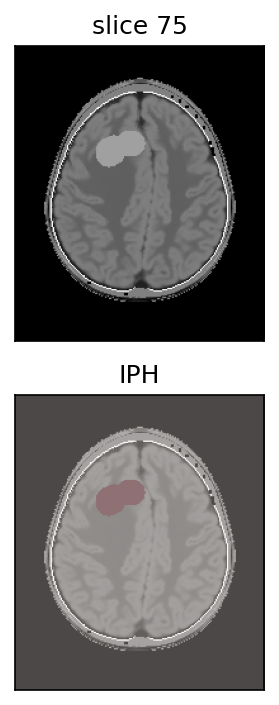

In [50]:
from utils import show_lesions
phantom.insert_lesion('IPH', mass_effect=True)
show_lesions(phantom)

In [51]:
from utils import scrollview

scrollview(phantom.get_CT_number_phantom())

interactive(children=(IntSlider(value=94, description='idx', max=188), Output()), _dom_classes=('widget-intera…

#### Introduce Random Affine Augmentations

To simulate a small amount of patient positioning variability

In [52]:
from monai.transforms import RandAffine
import numpy as np
randaffine = RandAffine(prob=0.5, rotate_range = [np.pi/4, np.pi/20, np.pi/20], translate_range=[10, 10, 10], scale_range=[0.1, 0.1, 0.1], padding_mode="border")

scrollview(randaffine(phantom.get_CT_number_phantom()))

interactive(children=(IntSlider(value=94, description='idx', max=188), Output()), _dom_classes=('widget-intera…

TODO: if CT numbers seem off, I can look into updating the thresholds in the [config file](https://github.com/xcist/phantoms-voxelized/blob/main/DICOM_to_voxelized/DICOM_to_voxelized_example_head.cfg) appropriately to get the best match in CT numbers (could do something like grab the unique values since I'm starting from ground truth, they are [currently configured](https://github.com/brandonjnelsonFDA/PedSilicoICH/blob/master/src/pedsilicoICH/ground_truth_definition/phantoms.py#L23) for abdominal imaging, rather than head.

Example of [normal brain CT](https://nbia.cancerimagingarchive.net/viewer/?study=1.3.6.1.4.1.14519.5.2.1.3098.5025.922017993220231365363448902707&series=1.3.6.1.4.1.14519.5.2.1.3098.5025.127673560102649811051571885155&token=eyJhbGciOiJIUzI1NiIsInR5cCIgOiAiSldUIiwia2lkIiA6ICJkZGFhMGY3YS1kZTBmLTRkYWQtYjM1ZS05MjljYjBiMTY3YjgifQ.eyJleHAiOjE3MDQ0MDA4NDYsImlhdCI6MTcwNDM5MzY0NiwianRpIjoiZDU4YTI0M2YtNGQwZi00MjljLTg0NDQtMGI5MjJjNzUzNWQ0IiwiaXNzIjoiaHR0cHM6Ly9rZXljbG9hay5kYm1pLmNsb3VkL2F1dGgvcmVhbG1zL1RDSUEiLCJhdWQiOiJhY2NvdW50Iiwic3ViIjoiZjowMTliNTYzNC1kYWJkLTQyMTEtYTQxZC03MjNjNDRhZmNmZmQ6bmJpYV9ndWVzdCIsInR5cCI6IkJlYXJlciIsImF6cCI6Im5iaWEiLCJzZXNzaW9uX3N0YXRlIjoiYzc5OTIxMTItZjcyYS00OWY5LWI0ZTMtOWY3ZTFmN2I0NzQ5IiwiYWNyIjoiMSIsImFsbG93ZWQtb3JpZ2lucyI6WyJodHRwczovL3NlcnZpY2VzLmNhbmNlcmltYWdpbmdlYXJjaGl2ZS5uZXQiLCJodHRwczovL25iaWEuY2FuY2VyaW1hZ2luZ2VhcmNoaXZlLm5ldCIsImh0dHBzOi8vd3d3LmNhbmNlcmltYWdpbmdlYXJjaGl2ZS5uZXQiLCIqIiwiaHR0cDovL3RjaWEtbmJpYS0yLmFkLnVhbXMuZWR1OjQ1MjEwIiwiaHR0cHM6Ly9jYW5jZXJpbWFnaW5nZWFyY2hpdmUubmV0IiwiaHR0cDovL3RjaWEtbmJpYS0xLmFkLnVhbXMuZWR1OjQ1MjEwIiwiaHR0cHM6Ly9wdWJsaWMuY2FuY2VyaW1hZ2luZ2VhcmNoaXZlLm5ldCJdLCJyZWFsbV9hY2Nlc3MiOnsicm9sZXMiOlsib2ZmbGluZV9hY2Nlc3MiLCJkZWZhdWx0LXJvbGVzLXRjaWEiLCJ1bWFfYXV0aG9yaXphdGlvbiJdfSwicmVzb3VyY2VfYWNjZXNzIjp7ImFjY291bnQiOnsicm9sZXMiOlsibWFuYWdlLWFjY291bnQiLCJtYW5hZ2UtYWNjb3VudC1saW5rcyIsInZpZXctcHJvZmlsZSJdfX0sInNjb3BlIjoib3BlbmlkIHByb2ZpbGUgZW1haWwiLCJzaWQiOiJjNzk5MjExMi1mNzJhLTQ5ZjktYjRlMy05ZjdlMWY3YjQ3NDkiLCJlbWFpbF92ZXJpZmllZCI6dHJ1ZSwibmFtZSI6Ik5CSUEgR3Vlc3QiLCJwcmVmZXJyZWRfdXNlcm5hbWUiOiJuYmlhX2d1ZXN0IiwiZ2l2ZW5fbmFtZSI6Ik5CSUEiLCJmYW1pbHlfbmFtZSI6Ikd1ZXN0IiwiZW1haWwiOiJuYmlhX2d1ZXN0QGNhbmNlcmltYWdpbmdhcmNoaXZlLm5ldCJ9.q7c8o4AZK8cnCMYmZD_TjGvGyLIAZBysMJNIVV3agrE) for reference:

### Running CT Scans: the `Scanner` class

In [53]:
phantom.patient_name = 'small phantom with lesion'
scanner = Scanner(phantom)
scanner

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 0.800000011920929-mm pixels (XY), 0.800000011920929-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ncat_adipose', 'ncat_water', 'ncat_brain', 'ncat_skull']
* mu values (/cm): [0.18, 0.21, 0.21, 0.46]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.16, 0.2, 0.21, 0.27]
* Thresholds (HU): [-200.0, -10.0, 10.0, 300.0]
*********************************************
* Calculating volume fraction maps for 4 materials and 189 slices...
* Writing volume fraction files for 4 materials and 189 slices, plus the HU data...
* Writing /tmp/


        <class 'VITools.image_acquisition.Scanner'> default
        Scanner: Scanner_Default
        Simulation Platform: CATSIM
        

Based on the size of the phantom we can get an estimate of how many scans are required to cover it, from there we can either keep the full range or modify accordingly, we can also set the table speed if we want to use helical acquisition for faster scan times (although I don't yet have helical acquisitions figured out yet, see [github issue](https://github.com/xcist/main/issues/73) on this and the [helical mode example](https://github.com/xcist/main/blob/master/gecatsim/examples/Sim_Sample_Helical.py).

recommended range: (-54, 69) mm


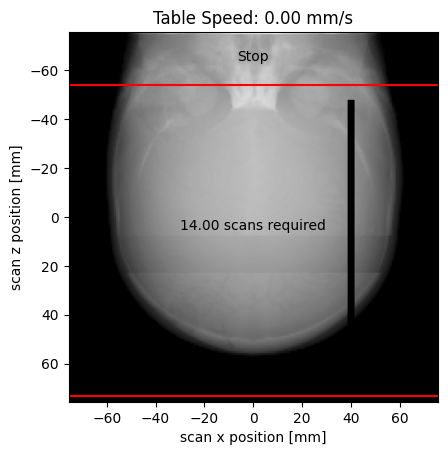

In [55]:
suggested_start_mm, suggested_end_mm = scanner.recommend_scan_range()
print(f'recommended range: ({suggested_start_mm}, {suggested_end_mm}) mm')
scanner.scout_view(startZ=suggested_start_mm, endZ=suggested_end_mm)

Arrow indicates table direction, it translates here with the base of the skull moving vertically

For a quick test let's do 1 scan so adjust the extent accordingly

Convert the lesion Z level from pixel coordinates to the table coordinates so we can selectively scan around the lesion for faster run times for this demo.

15.600000232458115 12.600000232458115 19.600000232458115


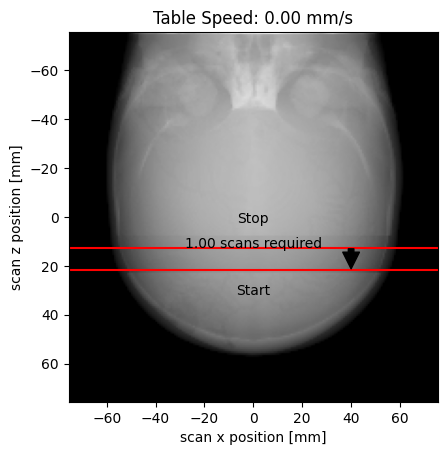

In [56]:
lesion_level_mm = (phantom.get_CT_number_phantom().shape[0]/2 - phantom._lesion_coords[0][0])*phantom.dz
center = lesion_level_mm
width = 7

startZ = center - width//2
endZ = startZ + width

print(center, startZ, endZ)
scanner.scout_view(startZ=startZ, endZ=endZ)

Look at how much faster we can scan with helical mode!

Still unclear how to do recon in helical mode...

there is 
```python
scanner.xcist.cfg.recon.reconType = 'helical_equiAngle'
```

as discussed here: https://github.com/xcist/main/issues/61#issuecomment-1955840993



In [57]:
scanner.run_scan(kVp=120, mA=200, startZ=startZ, endZ=endZ, views=500)

scan: 1/1
Airscan
Offset scan
Phantom scan


  0%|          | 0/500 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


100%|██████████| 500/500 [02:24<00:00,  3.45it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.



        <class 'VITools.image_acquisition.Scanner'> default
        Scanner: Scanner_Default
        Simulation Platform: CATSIM
        

In [58]:
scanner.run_recon(kernel='soft')

fov size: 250.0
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...



        <class 'VITools.image_acquisition.Scanner'> default
        Scanner: Scanner_Default
        Simulation Platform: CATSIM
        
Recon: (7, 512, 512) 25.0 cm fov
Projections: (500, 16, 900)

In [59]:
scrollview(scanner.recon, 'brain')

interactive(children=(IntSlider(value=3, description='idx', max=6), Output()), _dom_classes=('widget-interact'…

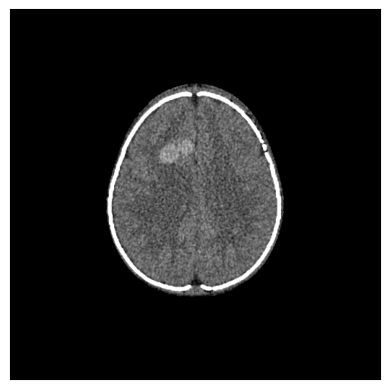

In [60]:
ctshow(scanner.recon, 'brain')

Text(0, 0.5, 'View Angle [degrees]')

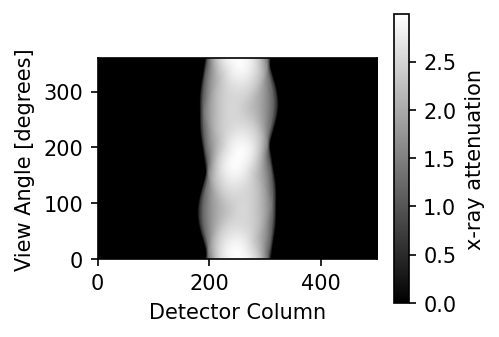

In [61]:
plt.figure(figsize=(3,2.5), dpi=150)
plt.imshow(scanner.projections[:, 4, :], cmap='gray', extent=[0, 500, 0, 360])
plt.colorbar(label='x-ray attenuation')
plt.xlabel('Detector Column')
plt.ylabel('View Angle [degrees]')

In [62]:
scanner.run_recon(sliceThickness=1)

fov size: 250.0
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...



        <class 'VITools.image_acquisition.Scanner'> default
        Scanner: Scanner_Default
        Simulation Platform: CATSIM
        
Recon: (7, 512, 512) 25.0 cm fov
Projections: (500, 16, 900)

In [63]:
scrollview(scanner.recon ,'brain')

interactive(children=(IntSlider(value=3, description='idx', max=6), Output()), _dom_classes=('widget-interact'…

In [64]:
scrollview(scanner.projections.transpose(1,0,2), (4, 2))

interactive(children=(IntSlider(value=8, description='idx', max=15), Output()), _dom_classes=('widget-interact…

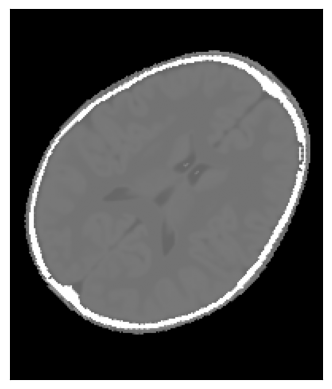

In [65]:
from monai.transforms import Affine
rotate = Affine(rotate_params=np.deg2rad(45), padding_mode='border')
phantom.apply_transform(rotate)
img_transform = phantom.get_CT_number_phantom()
ctshow(img_transform[100])

In [66]:
scanner.phantom._lesion[0].shape

torch.Size([189, 233, 197])

In [67]:
mask = scanner.get_lesion_mask(startZ=startZ, endZ=endZ)

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 0.800000011920929-mm pixels (XY), 0.800000011920929-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ICRU_lung_adult_healthy', 'water']
* mu values (/cm): [0.05, 0.21]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.0, 0.19]
* Thresholds (HU): [-1000.0, -100.0]
*********************************************
* Calculating volume fraction maps for 2 materials and 189 slices...
* Writing volume fraction files for 2 materials and 189 slices, plus the HU data...
* Writing /tmp/tmpp1uedpxp/small phantom with lesion/lesion_mask/lesion 

  0%|          | 0/100 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.


  1%|          | 1/100 [00:01<01:41,  1.02s/it]

in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated a total of     66 MB.


100%|██████████| 100/100 [00:12<00:00,  7.98it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
fov size: 250.0
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...


Text(0.5, 1.0, 'Lesion Mask Overlay')

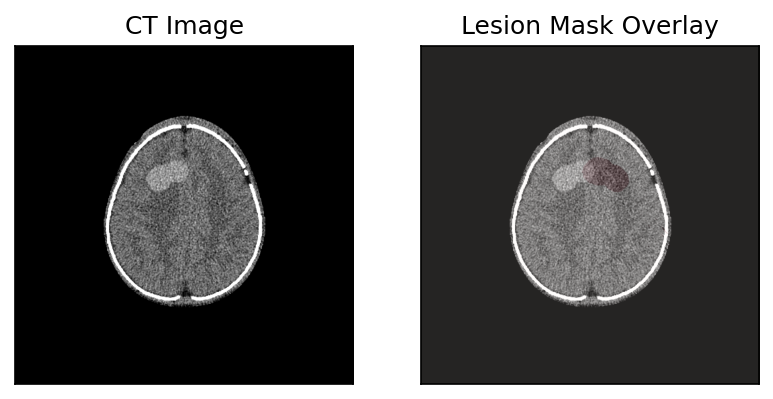

In [68]:
idx = 4
display = 'brain'
f, axs = plt.subplots(1, 2, dpi=150)
ctshow(scanner.recon[idx], display, fig=f, ax=axs[0])
ctshow(scanner.recon[idx], display, fig=f, ax=axs[1])
axs[1].imshow(mask[idx], alpha=0.15, cmap='Reds')
axs[0].set_title('CT Image')
axs[1].set_title('Lesion Mask Overlay')

### Organize it into Study object

The `Study` object holds both the patient `Phantom` instance and the scanner `Scanner` instance and stores the relevant scan details

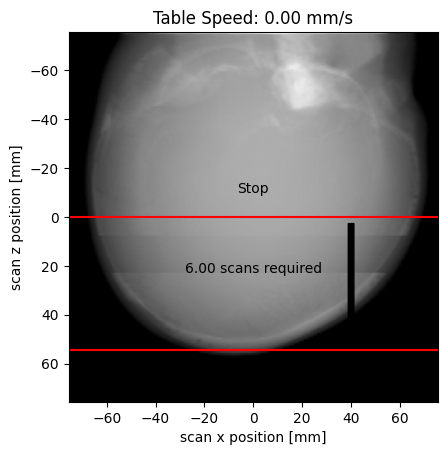

In [69]:
startZ = 0
endZ = 50
scanner.scout_view(startZ=startZ, endZ=endZ)

In [70]:
from insilicoICH.study import Study, run_study
study = Study(scanner, 'pilot')
study


        study name: pilot
        Phantom details:
        ----------------
        
        Phantom Class: NIHPD_Head
        Age (years): 6.5
        Shape (voxels): [189, 233, 197]
        Size (mm): [151.20000225 186.40000278 157.60000235]
        
        Number of lesions: 1
        Lesion locations [voxel index (z, x, y)]: [(np.int64(75), np.int64(88), np.int64(80))]
        Mass effect: True
        

        Scanner details:
        ----------------
        Scanner: 
        <class 'VITools.image_acquisition.Scanner'> default
        Scanner: Scanner_Default
        Simulation Platform: CATSIM
        
Recon: (7, 512, 512) 25.0 cm fov
Projections: (500, 16, 900)

        Study details:
        --------------
        None
        

In [71]:
study.run_study('test', kVp=120, mA=500, views=100, zspan=(startZ, endZ))

scan: 1/6
Airscan
Offset scan
Phantom scan


  0%|          | 0/100 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


100%|██████████| 100/100 [00:30<00:00,  3.32it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
scan: 2/6
Airscan
Offset scan
Phantom scan


...

  1%|          | 1/100 [00:01<01:40,  1.01s/it]

in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated a total of     66 MB.


100%|██████████| 100/100 [00:12<00:00,  7.92it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C ar


        study name: pilot
        Phantom details:
        ----------------
        
        Phantom Class: NIHPD_Head
        Age (years): 6.5
        Shape (voxels): [189, 233, 197]
        Size (mm): [151.20000225 186.40000278 157.60000235]
        
        Number of lesions: 1
        Lesion locations [voxel index (z, x, y)]: [(np.int64(75), np.int64(88), np.int64(80))]
        Mass effect: True
        

        Scanner details:
        ----------------
        Scanner: 
        <class 'VITools.image_acquisition.Scanner'> default
        Scanner: Scanner_Default
        Simulation Platform: CATSIM
        
Recon: (42, 512, 512) 25.0 cm fov
Projections: (100, 16, 900)

        Study details:
        --------------
                                 Name  Age  kVp   mA  Views ReconKernel  \
0   small phantom with lesion  6.5  120  500    100    standard   
1   small phantom with lesion  6.5  120  500    100    standard   
2   small phantom with lesion  6.5  120  500    100    standar

In [72]:
study.metadata

,Name,Age,kVp,mA,Views,ReconKernel,SliceThickness(mm),LesionAttenuation(HU),LesionVolume(mL),Subtype,MassEffect,CenterX,CenterY,CenterZ,FOV(mm),ImageFilePath,MaskFilePath
0,small phantom with lesion,6.5,120,500,100,standard,1,None,[0.0],None,None,NaN,NaN,NaN,250,test/small phantom with lesion/dicoms/small ph...,test/small phantom with lesion/lesion_masks/sm...
1,small phantom with lesion,6.5,120,500,100,standard,1,None,[0.0],None,None,NaN,NaN,NaN,250,test/small phantom with lesion/dicoms/small ph...,test/small phantom with lesion/lesion_masks/sm...
2,small phantom with lesion,6.5,120,500,100,standard,1,None,[0.0],None,None,NaN,NaN,NaN,250,test/small phantom with lesion/dicoms/small ph...,test/small phantom with lesion/lesion_masks/sm...
3,small phantom with lesion,6.5,120,500,100,standard,1,None,[0.0],None,None,NaN,NaN,NaN,250,test/small phantom with lesion/dicoms/small ph...,test/small phantom with lesion/lesion_masks/sm...
4,small phantom with lesion,6.5,120,500,100,standard,1,None,[0.0],None,None,NaN,NaN,NaN,250,test/small phantom with lesion/dicoms/small ph...,test/small phantom with lesion/lesion_masks/sm...
5,small phantom with lesion,6.5,120,500,100,standard,1,None,[0.0],None,None,NaN,NaN,NaN,250,test/small phantom with lesion/dicoms/small ph...,test/small phantom with lesion/lesion_masks/sm...
6,small phantom with lesion,6.5,120,500,100,standard,1,None,[0.0],None,None,NaN,NaN,NaN,250,test/small phantom with lesion/dicoms/small ph...,test/small phantom with lesion/lesion_masks/sm...
7,small phantom with lesion,6.5,120,500,100,standard,1,None,[0.0],None,None,NaN,NaN,NaN,250,test/small phantom with lesion/dicoms/small ph...,test/small phantom with lesion/lesion_masks/sm...
8,small phantom with lesion,6.5,120,500,100,standard,1,None,[0.0],None,None,NaN,NaN,NaN,250,test/small phantom with lesion/dicoms/small ph...,test/small phantom with lesion/lesion_masks/sm...
9,small phantom with lesion,6.5,120,500,100,standard,1,[50.0],[0.2086162567138672],[IPH],True,195.0,278.0,14.0,250,test/small phantom with lesion/dicoms/small ph...,test/small phantom with lesion/lesion_masks/sm...


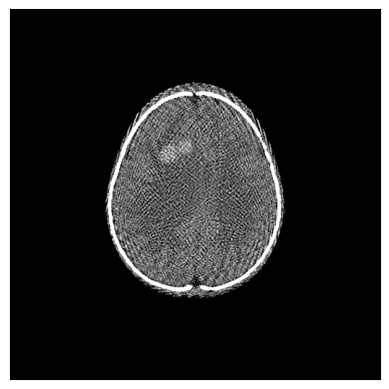

In [73]:
ctshow(study.scanner.recon[10], 'brain')

In [74]:
study.images.shape, study.lesion.shape

((42, 512, 512), (42, 512, 512))

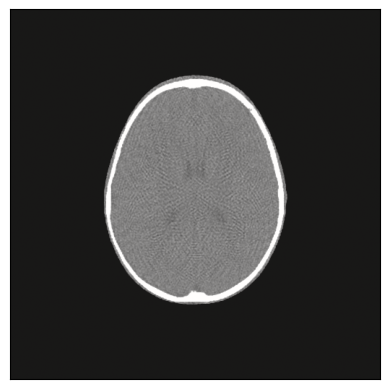

In [75]:
ctshow(study.images)
plt.imshow(study.lesion[0], cmap='Reds', alpha=0.1)